In [44]:
from pylab import *
import Fluid_CP as FCP
import Compressor_model_CP as CM
import compressor_model as cm
import plotDiag_Th_Ts as Diag


The following is our compressor model 

In [23]:
T_ev = 10.0
T_co = 60.0
DeltaT_sh = 2.0
DeltaT_sc = 2.0
D = 30.0              #mm
param = [T_ev,T_co,DeltaT_sh,DeltaT_sc,D]
eta_is, m_dot = cm.recip_comp_corr_SP(param,"Propane")
print("eta_is:", eta_is)
print("Mass Flow:", m_dot, "kg/s")

eta_is: 0.6599306908267419
Mass Flow: 0.031164332641966396 kg/s


This to get the basic info for the fluid properties

In [ ]:
print("Propane:")
print(FCP.get_fluid_info("Propane"))

print("R1234yf:")
print(FCP.get_fluid_info("R1234yf"))

print("Dimethyl ether(DME):")
print(FCP.get_fluid_info("DME"))

$$\eta_{is} = \frac{h_{out,is}-h_{in}}{h_{out}-h_{in}}$$
$$h_{out}=h_{in}+\frac{h_{out,is}-h_{in}}{\eta_{is}}$$

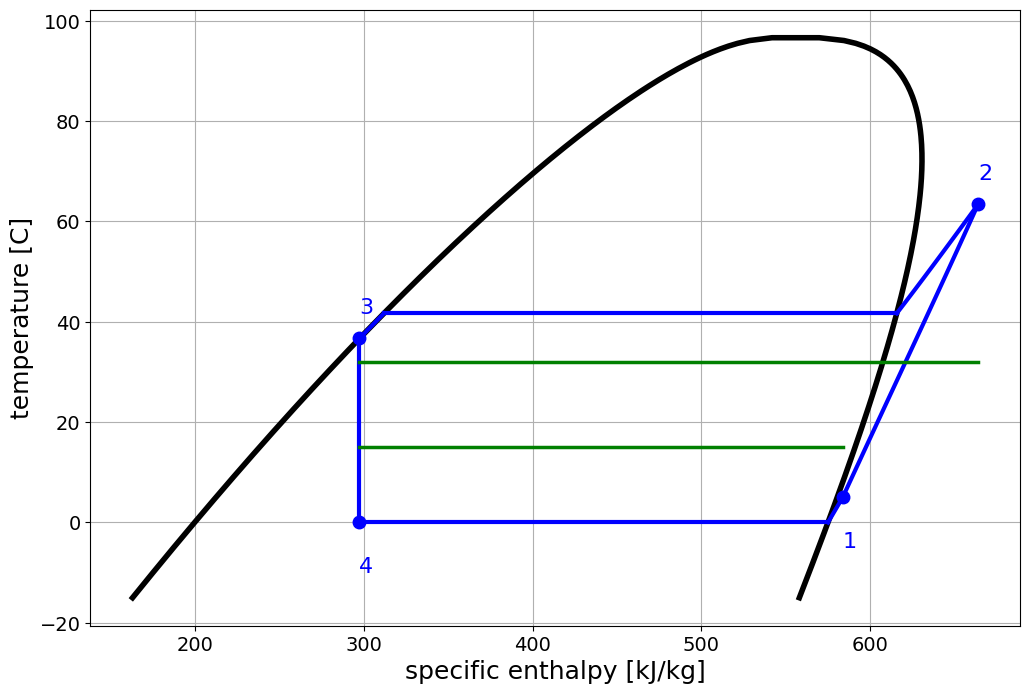

In [47]:
T_co = 0.0
DeltaT_sh = 5.0
DeltaT_sc = 5.0
Fluid = "Propane"
Eh = "CBar"
pressure_ratio = 3.0

state_1_x1 = FCP.state(["T","x"],[T_co,1],Fluid,Eh)
state_1_sh = FCP.state(["T","p"],[T_co+DeltaT_sh,state_1_x1["p"]],Fluid,Eh)
state_2_is = FCP.state(["p","s"],[state_1_x1["p"]*pressure_ratio,state_1_sh["s"]],Fluid,Eh)

h_2_vp = state_1_sh["h"] + (state_2_is["h"]-state_1_sh["h"])/eta_is

state_2_vp = FCP.state(["p","h"],[state_2_is["p"],h_2_vp],Fluid,Eh)
state_3_x0 = FCP.state(["p","x"],[state_2_is["p"],0],Fluid,Eh)
state_3_sc = FCP.state(["p","T"],[state_2_is["p"],state_3_x0["T"]-DeltaT_sc],Fluid,Eh)
state_4_xp = FCP.state(["h","p"],[state_3_sc["h"],state_1_x1["p"]],Fluid,Eh)

#print(state_1_x1)
#print(state_1_sh)
#print(state_2_is)
#print(state_2_vp)
#print(state_3_x0)
#print(state_3_sc)
#print(state_4_xp)

Diag.Th(state_1_sh,state_2_vp,state_3_sc,state_4_xp,[32.0,32.0],[15.0,15.0],Fluid,Eh)

def ac_cycle(compressor_size, refrigerant):
    
    
    return None